# Training the ML Warm-Start Model

This notebook shows the **full training pipeline** for the ML warm-start
predictor that accelerates VQE convergence.

## Pipeline Overview

1. **Data Collection** — Run many independent VQE optimisations for each
   configuration and store (features, parameters) pairs.
2. **Model Training** — Train one MLP neural network per configuration key
   with circular encoding (sin/cos) for periodic parameters.
3. **Quality Diagnostics** — Inspect predicted vs. true parameters.
4. **Benchmarking** — Compare warm-start vs. random initialisation.

> **Note:** Data collection is computationally expensive. For a quick demo,
> reduce `n_runs`. Pre-trained models are provided in `warmstart_models/`.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.ml_warmstart_vqe import (
    WarmStartCollector,
    WarmStartPredictor,
    benchmark_warmstart,
    plot_warmstart_quality,
)
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_PATH  = os.path.join('..', 'data', 'warmstart_data.json')
MODEL_DIR  = os.path.join('..', 'warmstart_models')

## Step 1 — Collect Training Data

Each `collect()` call runs `n_runs` independent VQE optimisations from random
initial parameters. Successfully converged runs are stored as training samples.

In [3]:
collector = WarmStartCollector(
    data_path=DATA_PATH,
    Lx=0.015, Ly=0.010
)

for mode in ('TM', 'TE'):
    for k in (0, 1):
        print(f'\n-- Collecting {mode} k={k} (vacuum) --')
        collector.collect(
            nx=2, ny=2, n_layers=2,
            mode_type=mode, k=k,
            plasma_density=0.0,
            n_runs=5,
        )

NE = 1e17
for mode in ('TM',):
    for k in (0, 1):
        print(f'\n-- Collecting {mode} k={k} (Ne={NE:.0e}) --')
        collector.collect(
            nx=2, ny=2, n_layers=2,
            mode_type=mode, k=k,
            plasma_density=NE,
            n_runs=5,
        )

collector.summary()


-- Collecting TM k=0 (vacuum) --
  [nx2_ny2_nl2_mtTM_k0] run 1/5 λ=135381.7545  (4.6s)
  [nx2_ny2_nl2_mtTM_k0] run 2/5 λ=135381.7545  (2.1s)
  [nx2_ny2_nl2_mtTM_k0] run 3/5 λ=135381.7545  (1.7s)
  [nx2_ny2_nl2_mtTM_k0] run 4/5 λ=135381.7546  (0.9s)
  [nx2_ny2_nl2_mtTM_k0] run 5/5 λ=135381.7545  (1.5s)
Collected 5 new samples for 'nx2_ny2_nl2_mtTM_k0' (total: 5)

-- Collecting TM k=1 (vacuum) --
  [nx2_ny2_nl2_mtTM_k1] run 1/5 λ=135381.7548  (8.1s)
  [nx2_ny2_nl2_mtTM_k1] run 2/5 λ=235948.0522  (3.1s)
  [nx2_ny2_nl2_mtTM_k1] run 3/5 λ=235948.0522  (5.3s)
  [nx2_ny2_nl2_mtTM_k1] run 4/5 λ=235948.0522  (7.9s)
  [nx2_ny2_nl2_mtTM_k1] run 5/5 λ=235948.0522  (6.5s)
Collected 5 new samples for 'nx2_ny2_nl2_mtTM_k1' (total: 5)

-- Collecting TE k=0 (vacuum) --
Attempt 1 - Iter 30: Cost 0.0000        
[Warning] Attempt 1 found eigenvalue 0.0000 (< 1). Restarting...
Attempt 2 - Iter 23: Cost 0.0000        
[Warning] Attempt 2 found eigenvalue 0.0000 (< 1). Restarting...
Attempt 3 - Iter 26: Cos

## Step 2 — Train the Predictor

The `WarmStartPredictor` trains one MLP per configuration key using circular
encoding (sin/cos) to respect the periodic parameter space.

In [4]:
predictor = WarmStartPredictor(
    data_path=DATA_PATH,
    model_dir=MODEL_DIR,
    max_iter=2000,
)

predictor.train(verbose=True)

print('\nTrained keys:')
for key in predictor.trained_keys():
    print(f'  - {key}')

  Trained 'nx2_ny2_nl2_mtTM_k0'  N=10  hidden=(64, 64)  R²=-0.1838
  Trained 'nx2_ny2_nl2_mtTM_k1'  N=10  hidden=(64, 64)  R²=-0.2684
  Trained 'nx2_ny2_nl2_mtTE_k0'  N=5  hidden=(64, 64)  R²=0.2840
  Trained 'nx2_ny2_nl2_mtTE_k1'  N=5  hidden=(64, 64)  R²=0.4177

Training complete.  4 model(s) ready.

Trained keys:
  - nx2_ny2_nl2_mtTM_k0
  - nx2_ny2_nl2_mtTM_k1
  - nx2_ny2_nl2_mtTE_k0
  - nx2_ny2_nl2_mtTE_k1


## Step 3 — Quality Diagnostics

Scatter plot of predicted vs. true parameters. A perfect predictor lies on y = x.

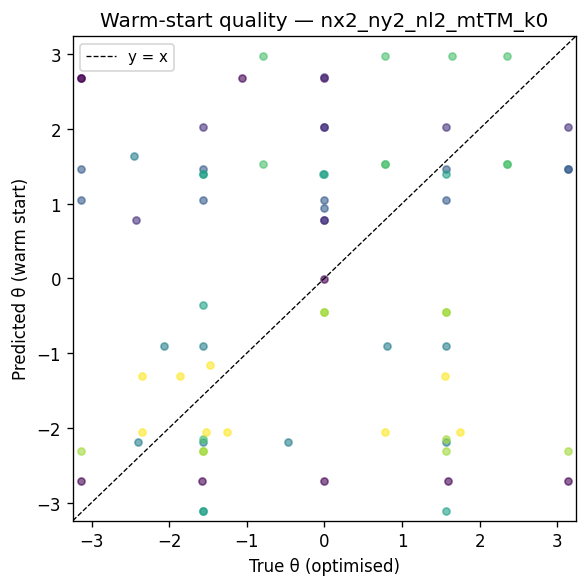

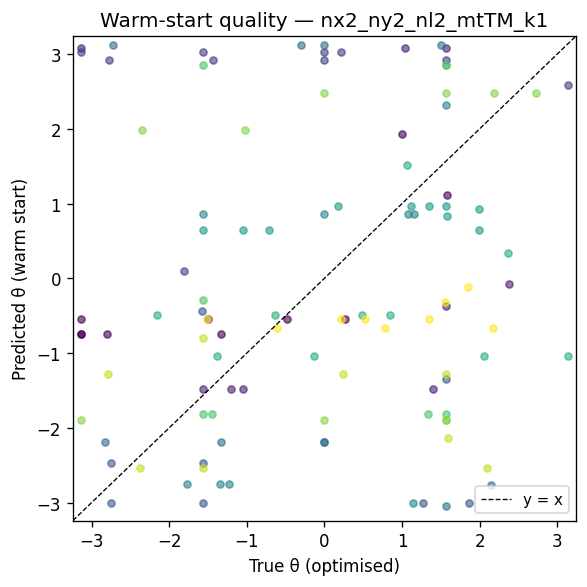

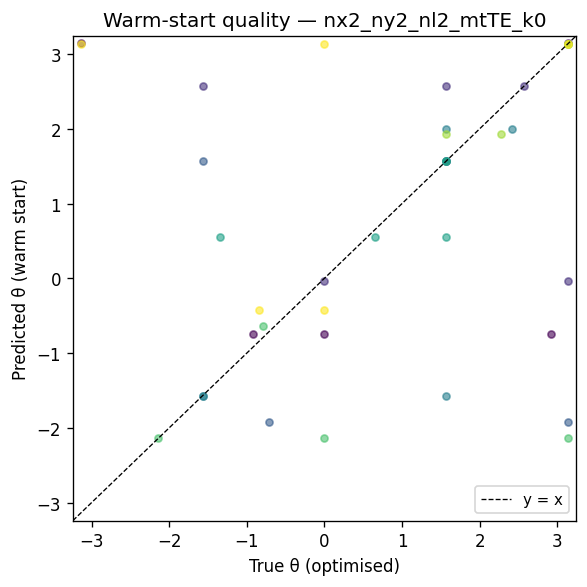

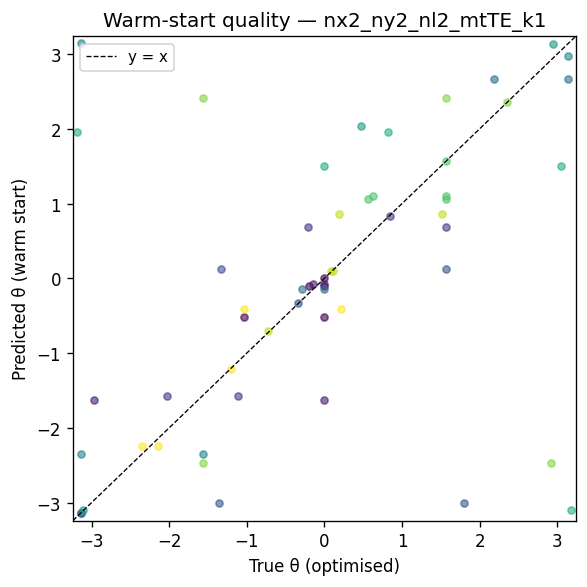

In [5]:
plot_warmstart_quality(DATA_PATH, predictor)

## Step 4 — Benchmark Warm-Start vs Random


── WARM START  (3 trials) ──
  trial 1: λ=135381.7545  iters=18
  trial 2: λ=135381.7545  iters=18
  trial 3: λ=135381.7545  iters=18

── RANDOM START  (3 trials) ──
  trial 1: λ=135381.7545  iters=16
  trial 2: λ=135381.7545  iters=16
  trial 3: λ=135381.7545  iters=15


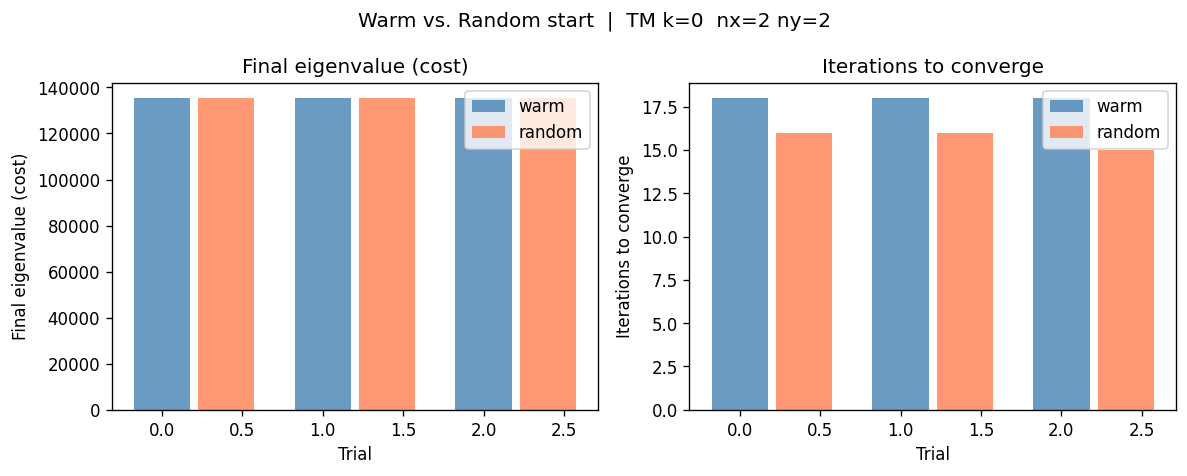


WARM START:
  Mean eigenvalue : 135381.7545 +/- 0.0000
  Mean iterations : 18.0 +/- 0.0

RANDOM START:
  Mean eigenvalue : 135381.7545 +/- 0.0000
  Mean iterations : 15.7 +/- 0.5


In [6]:
results = benchmark_warmstart(
    predictor,
    nx=2, ny=2, n_layers=2,
    mode_type='TM', k=0,
    plasma_density=0.0,
    n_trials=3,
)

for strat in ('warm', 'random'):
    eigs = [r[0] for r in results[strat]]
    iters = [r[1] for r in results[strat]]
    print(f'\n{strat.upper()} START:')
    print(f'  Mean eigenvalue : {np.mean(eigs):.4f} +/- {np.std(eigs):.4f}')
    print(f'  Mean iterations : {np.mean(iters):.1f} +/- {np.std(iters):.1f}')

## Step 5 — Verify Saved Models

In [7]:
print('Saved model files:')
if os.path.isdir(MODEL_DIR):
    for f in sorted(os.listdir(MODEL_DIR)):
        size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
        print(f'  {f}  ({size:.1f} KB)')
else:
    print('  (no models saved yet)')

Saved model files:
  nx2_ny2_nl2_mtTE_k0.joblib  (188.2 KB)
  nx2_ny2_nl2_mtTE_k0_scaler.joblib  (0.7 KB)
  nx2_ny2_nl2_mtTE_k1.joblib  (208.4 KB)
  nx2_ny2_nl2_mtTE_k1_scaler.joblib  (0.7 KB)
  nx2_ny2_nl2_mtTM_k0.joblib  (142.7 KB)
  nx2_ny2_nl2_mtTM_k0_scaler.joblib  (0.7 KB)
  nx2_ny2_nl2_mtTM_k1.joblib  (154.9 KB)
  nx2_ny2_nl2_mtTM_k1_scaler.joblib  (0.7 KB)
